# 🏦 Credit Risk Prediction — Full ML Pipeline
**Đồ án Máy học | LightGBM vs Random Forest vs Logistic Regression**

Dataset: `credit_risk_dataset.csv` (32,581 mẫu, 12 features)  
Bài toán: Phân loại nhị phân — dự đoán khả năng vỡ nợ (`loan_status`)

---
**Mục lục**
1. Load & Inspect Data  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing  
4. Training: Logistic Regression / Random Forest / LightGBM  
5. Evaluation & So sánh  
6. Feature Importance & SHAP  
7. Tổng kết


## 1. Setup & Load Data

In [1]:
%pip install lightgbm shap xgboost scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
import lightgbm as lgb

# ── Style ──────────────────────────────────────────────────
PALETTE = ["#4C72B0", "#55A868", "#C44E52"]
BLUE, GREEN, RED = PALETTE
BG = "#F8F9FA"
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
df = pd.read_csv("credit_risk_dataset.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape  : (32581, 12)
Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print("\n=== Target Distribution ===")
print(df['loan_status'].value_counts())
print(f"\nClass ratio: {(df['loan_status']==0).sum()} không vỡ nợ | {(df['loan_status']==1).sum()} vỡ nợ")

=== Missing Values ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Total missing: 4011

=== Target Distribution ===
loan_status
0    25473
1     7108
Name: count, dtype: int64

Class ratio: 25473 không vỡ nợ | 7108 vỡ nợ


## 2. Exploratory Data Analysis (EDA)

### 2.1 Phân phối biến mục tiêu `loan_status`

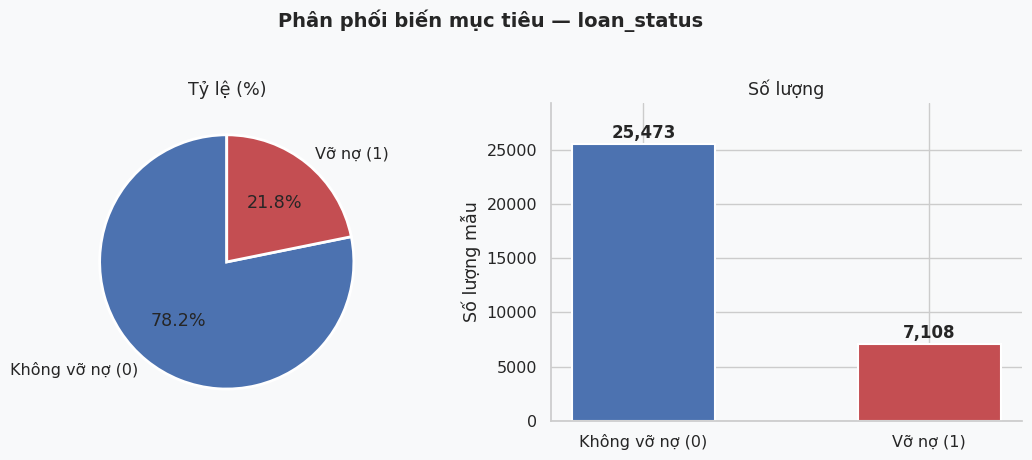

⚠️  Class imbalance: ~78% không vỡ nợ vs ~22% vỡ nợ → cần xử lý khi training


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=BG)
fig.suptitle("Phân phối biến mục tiêu — loan_status", fontsize=14, fontweight="bold", y=1.02)

counts = df["loan_status"].value_counts()
labels = ["Không vỡ nợ (0)", "Vỡ nợ (1)"]
colors_pie = ["#4C72B0", "#C44E52"]

axes[0].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90,
            colors=colors_pie, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Tỷ lệ (%)")

bars = axes[1].bar(labels, counts.values, color=colors_pie, edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Số lượng mẫu")
axes[1].set_title("Số lượng")
axes[1].set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

print("⚠️  Class imbalance: ~78% không vỡ nợ vs ~22% vỡ nợ → cần xử lý khi training")

### 2.2 Phân phối Numeric Features theo class

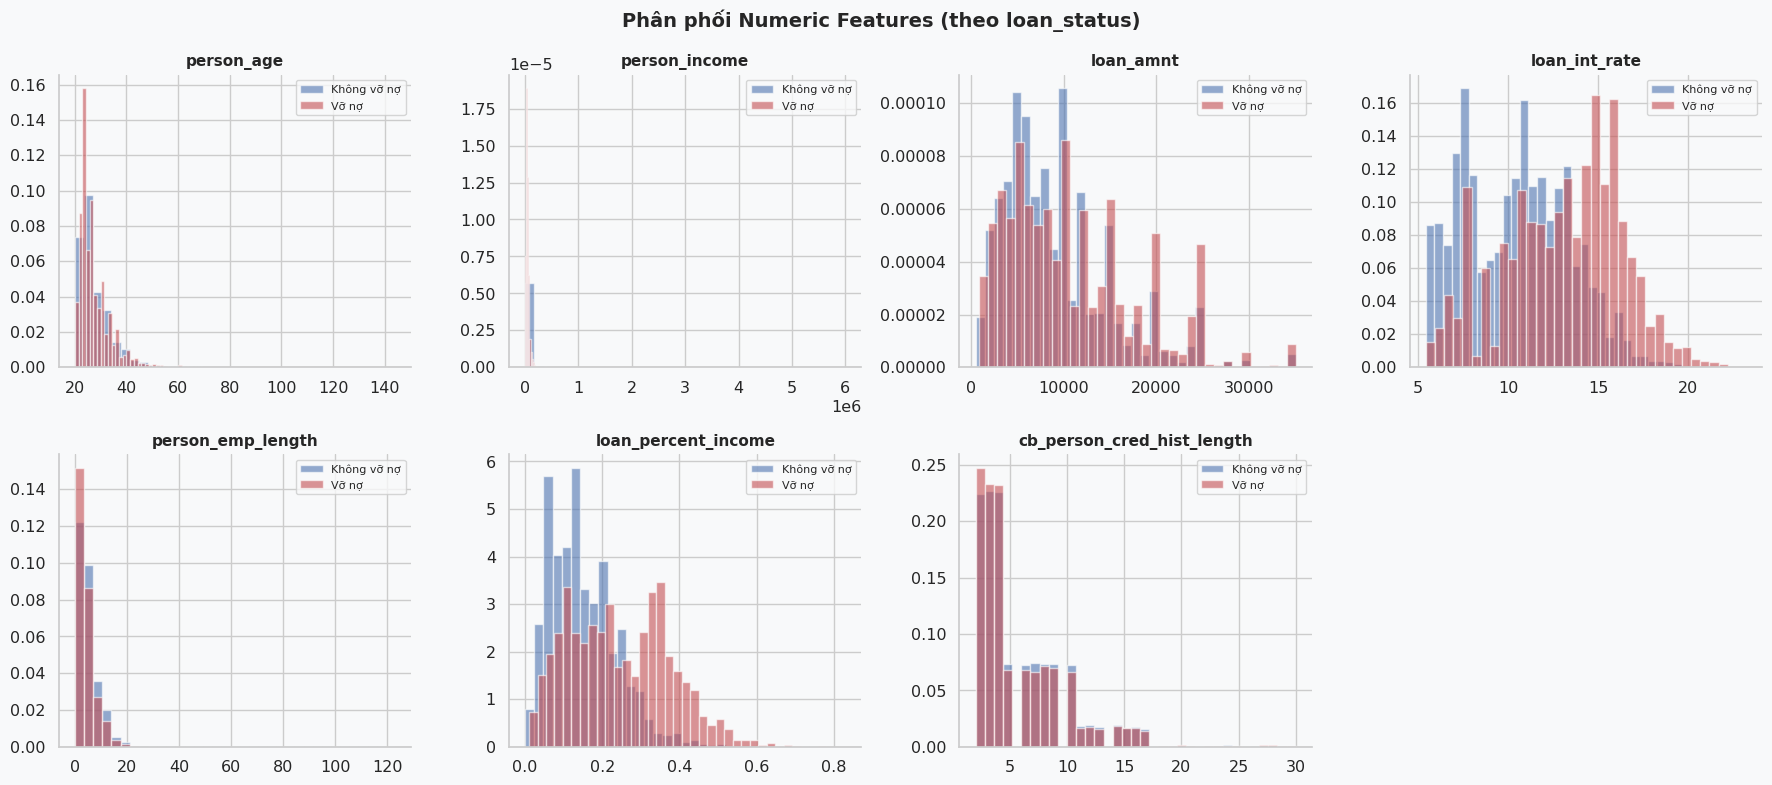

In [5]:
num_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate",
            "person_emp_length", "loan_percent_income", "cb_person_cred_hist_length"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor=BG)
fig.suptitle("Phân phối Numeric Features (theo loan_status)", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data0 = df[df["loan_status"] == 0][col].dropna()
    data1 = df[df["loan_status"] == 1][col].dropna()
    axes[i].hist(data0, bins=35, alpha=0.6, color=BLUE,  label="Không vỡ nợ", density=True)
    axes[i].hist(data1, bins=35, alpha=0.6, color=RED,   label="Vỡ nợ",       density=True)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 2.3 Categorical Features

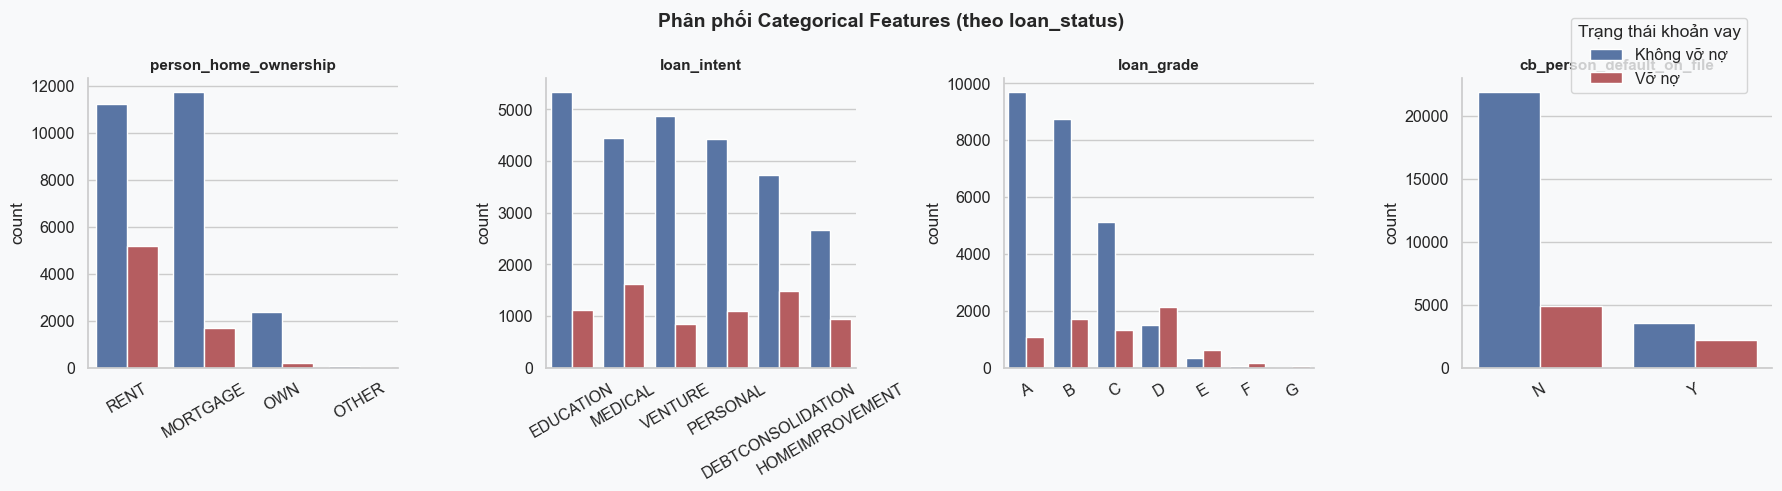

In [6]:
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor=BG)
fig.suptitle("Phân phối Categorical Features (theo loan_status)", fontsize=14, fontweight="bold")

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="loan_status", ax=ax, order=order,
                  palette={0: BLUE, 1: RED})
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove() # Ẩn legend riêng lẻ của từng ô con

# Tạo 1 legend chung duy nhất cho toàn bộ bức tranh ở góc trên bên phải
fig.legend(labels=["Không vỡ nợ", "Vỡ nợ"], loc="upper right", 
           bbox_to_anchor=(0.98, 0.98), title="Trạng thái khoản vay")

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

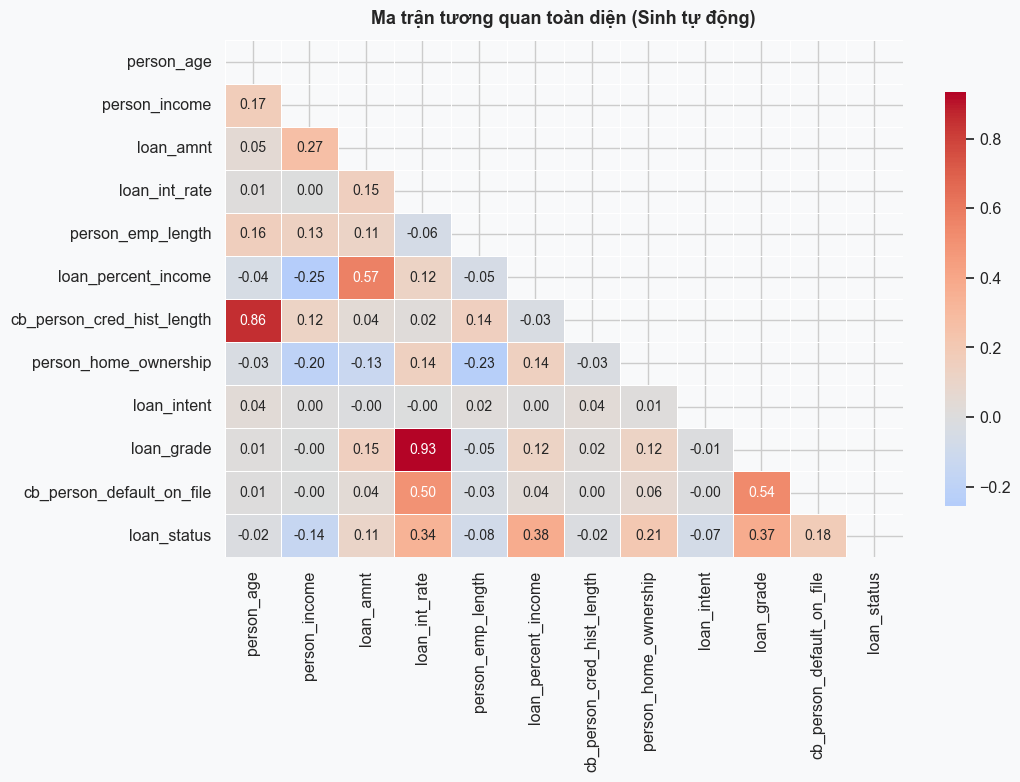

Hai biến có độ tương quan cao nhất với loan_status là:
   1. Khía cạnh 'loan_percent_income' với hệ số tương quan thực tế: 0.38
   2. Khía cạnh 'loan_grade' với hệ số tương quan thực tế: 0.37


In [9]:
# 1. Định nghĩa lại danh sách các cột (Bổ sung bước này để tránh lỗi NameError)
num_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate",
            "person_emp_length", "loan_percent_income", "cb_person_cred_hist_length"]

cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

# 2. Tạo một bản copy dữ liệu để tính toán tương quan (bao gồm cả biến chữ đã mã hóa)
df_corr_calc = df.copy()

# Mã hóa các cột chữ thành số (cat.codes) để đưa vào ma trận tương quan tự động
for col in cat_cols:
    df_corr_calc[col] = df_corr_calc[col].astype('category').cat.codes

# 3. Tính ma trận tương quan trên tất cả các biến liên quan
all_features = num_cols + cat_cols
corr_matrix = df_corr_calc[all_features + ["loan_status"]].corr()

# 4. Tự động lấy ra độ tương quan của TẤT CẢ các biến đối với 'loan_status' (bỏ chính nó)
target_corr = corr_matrix["loan_status"].drop("loan_status")

# 5. Tìm 2 biến có mức độ tương quan mạnh nhất (dựa trên trị tuyệt đối để lấy cả thuận lẫn nghịch)
top_features = target_corr.abs().nlargest(2).index.tolist()

# Lấy giá trị tương quan thực tế từ ma trận của 2 biến này
corr_val1 = corr_matrix.loc[top_features[0], "loan_status"]
corr_val2 = corr_matrix.loc[top_features[1], "loan_status"]

# 6. VẼ BIỂU ĐỒ HEATMAP TOÀN DIỆN
fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 10}, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan toàn diện (Sinh tự động)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 7. IN KẾT LUẬN TỰ ĐỘNG TỪ KẾT QUẢ CHẠY THỰC TẾ
print(f"Hai biến có độ tương quan cao nhất với loan_status là:")
print(f"   1. Khía cạnh '{top_features[0]}' với hệ số tương quan thực tế: {corr_val1:.2f}")
print(f"   2. Khía cạnh '{top_features[1]}' với hệ số tương quan thực tế: {corr_val2:.2f}")

### 2.5 Phát hiện Outliers

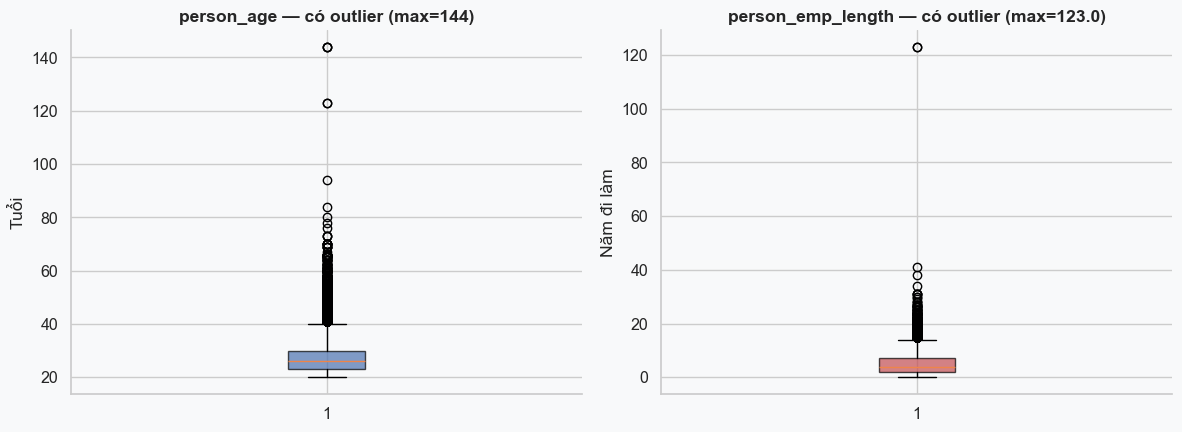

person_age max      : 144  → bất thường, cần loại bỏ
person_emp_length max: 123.0 → bất thường, cần loại bỏ


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=BG)

# Sử dụng f-string cho tiêu đề tự động lấy giá trị Max từ dữ liệu
axes[0].boxplot(df["person_age"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.7))
axes[0].set_title(f"person_age — có outlier (max={df['person_age'].max()})", fontweight="bold")
axes[0].set_ylabel("Tuổi")

axes[1].boxplot(df["person_emp_length"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor=RED, alpha=0.7))
axes[1].set_title(f"person_emp_length — có outlier (max={df['person_emp_length'].max()})", fontweight="bold")
axes[1].set_ylabel("Năm đi làm")

plt.tight_layout()
plt.show()

print(f"person_age max      : {df['person_age'].max()}  → bất thường, cần loại bỏ")
print(f"person_emp_length max: {df['person_emp_length'].max()} → bất thường, cần loại bỏ")

## 3. Preprocessing

In [11]:
df_clean = df.copy()
df_clean = df_clean[(df_clean["person_age"] <= 100) & (df_clean["person_emp_length"] <= 60)]
print(f"✅ Outliers removed. Còn lại: {len(df_clean)} rows")

# ─── 3.2 Tách X, y và Chia Train/Test TRƯỚC để chống Data Leakage ───
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Train/Test Split xong. Train: {X_train.shape} | Test: {X_test.shape}")

# Tính scale_pos_weight phục vụ cho cấu hình LightGBM sau này
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()


# ─── MÔ HÌNH 1: CHUẨN BỊ DỮ LIỆU CHO LIGHTGBM (SIÊU ĐƠN GIẢN) ───
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

# Không cần điền khuyết, chỉ cần ép kiểu 'category' cho các cột chữ
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]
for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')
print("✅ Dữ liệu cho LightGBM: Đã sẵn sàng (Giữ nguyên NaN + Ép kiểu category)")


# ─── MÔ HÌNH 2 & 3: CHUẨN BỊ CHO RANDOM FOREST & LOGISTIC REGRESSION ───
# Bước A: Điền khuyết dựa trên thông tin tập TRAIN (Chống rò rỉ dữ liệu)
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Điền loan_int_rate theo median của loan_grade trong tập TRAIN
loan_grade_medians = X_train_imputed.groupby("loan_grade")["loan_int_rate"].median()
X_train_imputed["loan_int_rate"] = X_train_imputed.apply(
    lambda row: loan_grade_medians[row["loan_grade"]] if pd.isnull(row["loan_int_rate"]) else row["loan_int_rate"], axis=1
)
X_test_imputed["loan_int_rate"] = X_test_imputed.apply(
    lambda row: loan_grade_medians[row["loan_grade"]] if pd.isnull(row["loan_int_rate"]) else row["loan_int_rate"], axis=1
)

# Điền person_emp_length theo median của tập TRAIN
emp_median = X_train_imputed["person_emp_length"].median()
X_train_imputed["person_emp_length"].fillna(emp_median, inplace=True)
X_test_imputed["person_emp_length"].fillna(emp_median, inplace=True)

# Bước B: Mã hóa phù hợp cho từng mô hình
# 1. Cho Random Forest (Dùng One-Hot hoặc Label Encode đều được, ở đây dùng One-Hot cho đồng bộ)
# 2. Cho Logistic Regression (BẮT BUỘC dùng One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train_imputed, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_imputed, columns=cat_cols, drop_first=True)

# Đảm bảo tập test có số cột trùng khớp tập train sau khi One-Hot
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
print("✅ Dữ liệu cho RF & LR: Đã điền khuyết + One-Hot Encoding")

# Bước C: Scale riêng cho Logistic Regression
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_encoded)
X_test_lr_scaled = scaler.transform(X_test_encoded)
print("✅ Dữ liệu cho Logistic Regression: Đã được Scale")

✅ Outliers removed. Còn lại: 31679 rows
✅ Train/Test Split xong. Train: (25343, 11) | Test: (6336, 11)
✅ Dữ liệu cho LightGBM: Đã sẵn sàng (Giữ nguyên NaN + Ép kiểu category)
✅ Dữ liệu cho RF & LR: Đã điền khuyết + One-Hot Encoding
✅ Dữ liệu cho Logistic Regression: Đã được Scale


## 4. Training Models

### 4.1 Baseline 1 — Logistic Regression

In [13]:
t0 = time.time()
# Khởi tạo mô hình
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)

# SỬA TÊN BIẾN: Thay X_train_s bằng X_train_lr_scaled
lr.fit(X_train_lr_scaled, y_train)
t_lr = time.time() - t0

# SỬA TÊN BIẾN: Thay X_test_s bằng X_test_lr_scaled
lr_pred = lr.predict(X_test_lr_scaled)
lr_prob = lr.predict_proba(X_test_lr_scaled)[:, 1]

print(f"✅ Logistic Regression trained in {t_lr:.3f}s")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["Không vỡ nợ", "Vỡ nợ"]))

✅ Logistic Regression trained in 0.241s

Classification Report:
              precision    recall  f1-score   support

 Không vỡ nợ       0.93      0.82      0.87      4971
       Vỡ nợ       0.55      0.79      0.65      1365

    accuracy                           0.81      6336
   macro avg       0.74      0.80      0.76      6336
weighted avg       0.85      0.81      0.82      6336



### 4.2 Baseline 2 — Random Forest

In [14]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=12,
    class_weight="balanced", 
    random_state=42, 
    n_jobs=-1
)

# SỬA TÊN BIẾN: Dùng X_train_encoded đã được xử lý chữ và NaN
rf.fit(X_train_encoded, y_train)
t_rf = time.time() - t0

# SỬA TÊN BIẾN: Dùng X_test_encoded
rf_pred = rf.predict(X_test_encoded)
rf_prob = rf.predict_proba(X_test_encoded)[:, 1]

print(f"✅ Random Forest trained in {t_rf:.3f}s")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=["Không vỡ nợ", "Vỡ nợ"]))

✅ Random Forest trained in 2.403s

Classification Report:
              precision    recall  f1-score   support

 Không vỡ nợ       0.93      0.97      0.95      4971
       Vỡ nợ       0.88      0.75      0.81      1365

    accuracy                           0.92      6336
   macro avg       0.91      0.86      0.88      6336
weighted avg       0.92      0.92      0.92      6336



### 4.3 LightGBM ⭐

In [15]:
t0 = time.time()
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    scale_pos_weight=scale_pw,   # xử lý class imbalance dựa trên tỷ lệ động đã tính
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# SỬA TÊN BIẾN: Truyền X_train_lgb và X_test_lgb vào huấn luyện và đánh giá sớm (early stopping)
lgbm.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(-1)
    ]
)
t_lgbm = time.time() - t0

# SỬA TÊN BIẾN: Dự đoán trên tập X_test_lgb
lgbm_pred = lgbm.predict(X_test_lgb)
lgbm_prob = lgbm.predict_proba(X_test_lgb)[:, 1]

print(f"✅ LightGBM trained in {t_lgbm:.3f}s | Best iteration: {lgbm.best_iteration_}")
print("\nClassification Report:")
print(classification_report(y_test, lgbm_pred, target_names=["Không vỡ nợ", "Vỡ nợ"]))

✅ LightGBM trained in 3.457s | Best iteration: 500

Classification Report:
              precision    recall  f1-score   support

 Không vỡ nợ       0.94      0.97      0.96      4971
       Vỡ nợ       0.88      0.79      0.83      1365

    accuracy                           0.93      6336
   macro avg       0.91      0.88      0.89      6336
weighted avg       0.93      0.93      0.93      6336



## 5. Evaluation & So sánh

### 5.1 Bảng tổng hợp metrics

In [18]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)


In [20]:
results = {
    "Logistic Regression": dict(pred=lr_pred,    prob=lr_prob,    time=t_lr),
    "Random Forest":       dict(pred=rf_pred,    prob=rf_prob,    time=t_rf),
    "LightGBM":            dict(pred=lgbm_pred,  prob=lgbm_prob,  time=t_lgbm),
}

rows = []
for name, v in results.items():
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, v["pred"]), 4),
        "Precision": round(precision_score(y_test, v["pred"]), 4),
        "Recall":    round(recall_score(y_test, v["pred"]), 4),
        "F1-score":  round(f1_score(y_test, v["pred"]), 4),
        "AUC-ROC":   round(roc_auc_score(y_test, v["prob"]), 4),
        "Time (s)":  round(v["time"], 3),
    })

df_metrics = pd.DataFrame(rows).set_index("Model")
df_metrics.style.background_gradient(cmap="YlGn", subset=["Accuracy","F1-score","AUC-ROC"]) \
                .bar(subset=["Time (s)"], color="#C44E52", vmin=0)

,Accuracy,Precision,Recall,F1-score,AUC-ROC,Time (s)
Model,,,,,,
Logistic Regression,0.812800,0.545300,0.789700,0.645100,0.876500,0.241000
Random Forest,0.923600,0.879400,0.748000,0.808400,0.935200,2.403000
LightGBM,0.931800,0.884600,0.786100,0.832400,0.950300,3.457000


### 5.2 Biểu đồ so sánh Metrics

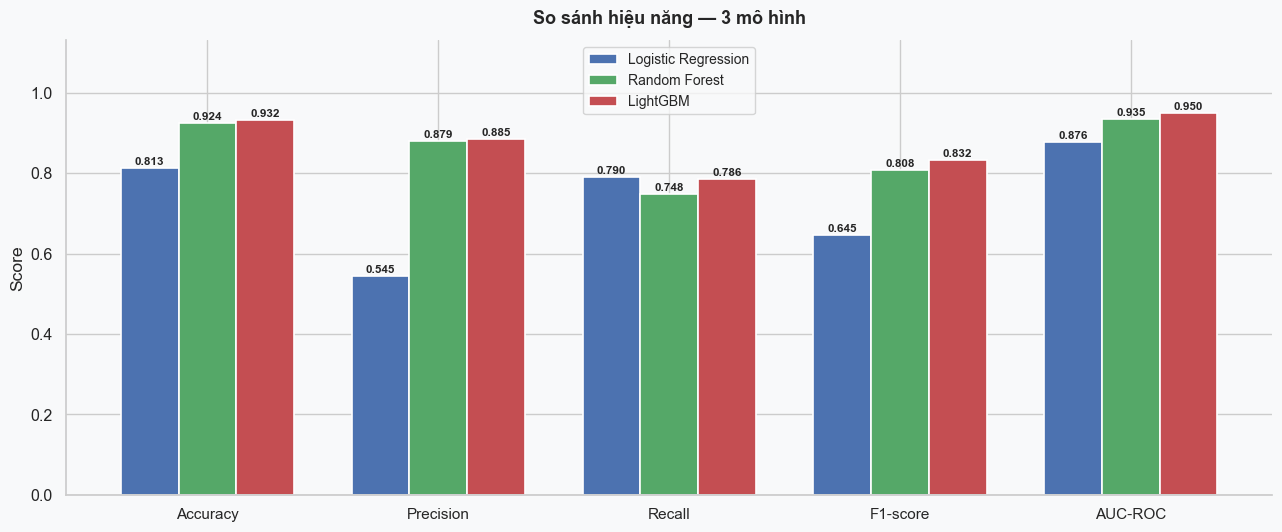

In [21]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]
fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=BG)
x     = np.arange(len(metric_cols))
width = 0.25

for i, (model, color) in enumerate(zip(df_metrics.index, PALETTE)):
    vals = df_metrics.loc[model, metric_cols].values.astype(float)
    bars = ax.bar(x + i*width, vals, width, label=model, color=color,
                  edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.13)
ax.set_ylabel("Score")
ax.set_title("So sánh hiệu năng — 3 mô hình", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 ROC Curve

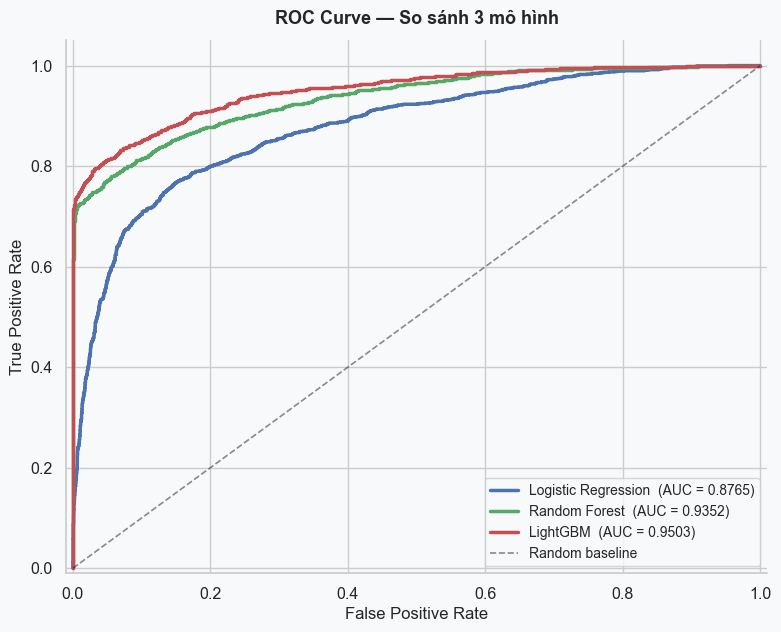

In [22]:
fig, ax = plt.subplots(figsize=(8, 6.5), facecolor=BG)
for (name, v), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, v["prob"])
    auc = roc_auc_score(y_test, v["prob"])
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1], "k--", lw=1.2, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — So sánh 3 mô hình", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.show()

### 5.4 Confusion Matrix

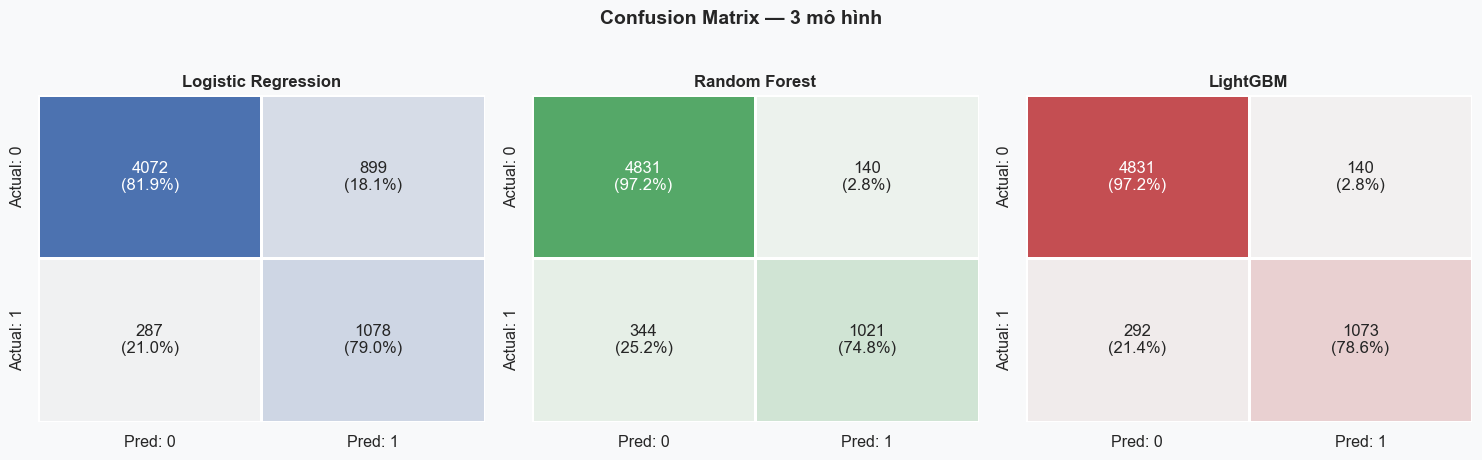

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor=BG)
fig.suptitle("Confusion Matrix — 3 mô hình", fontsize=14, fontweight="bold", y=1.02)

for ax, (name, v), color in zip(axes, results.items(), PALETTE):
    cm  = confusion_matrix(y_test, v["pred"])
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = [[f"{cm[i,j]}\n({pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]
    cmap  = sns.light_palette(color, as_cmap=True)
    sns.heatmap(cm, annot=annot, fmt="", cmap=cmap, ax=ax,
                xticklabels=["Pred: 0","Pred: 1"],
                yticklabels=["Actual: 0","Actual: 1"],
                linewidths=1, cbar=False, annot_kws={"size": 12})
    ax.set_title(name, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### 5.5 Training Time

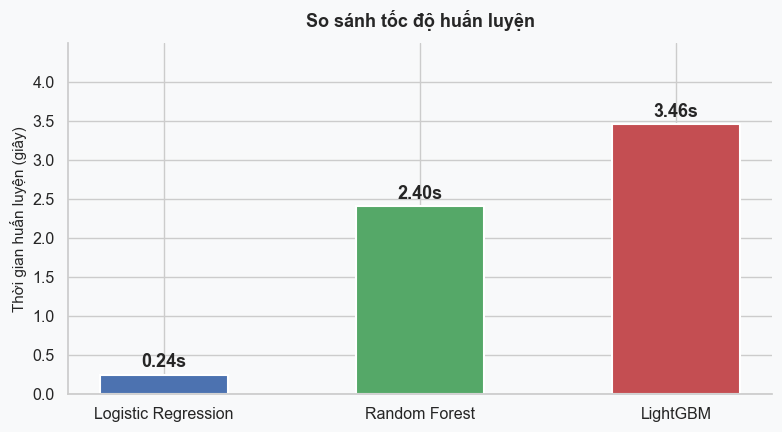

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)
models = list(results.keys())
times  = [results[m]["time"] for m in models]
bars   = ax.bar(models, times, color=PALETTE, edgecolor="white", linewidth=1.5, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{t:.2f}s", ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_ylabel("Thời gian huấn luyện (giây)", fontsize=11)
ax.set_title("So sánh tốc độ huấn luyện", fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(0, max(times) * 1.3)
plt.tight_layout()
plt.show()

## 6. Feature Importance & SHAP (LightGBM)

### 6.1 Feature Importance (split count)

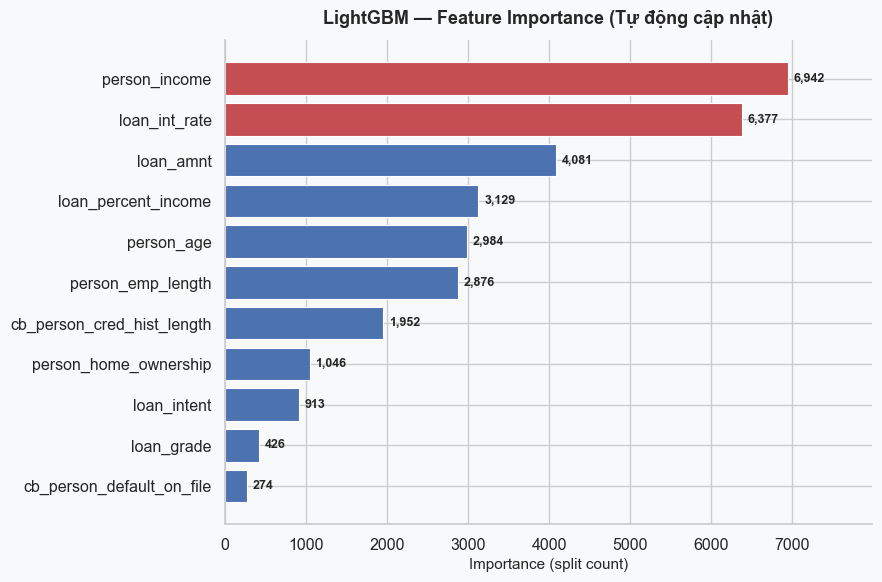

💡 Kết luận tự động từ mô hình LightGBM:
   - Hai thuộc tính quan trọng nhất quyết định phân nhánh cây là: 'person_income' (Top 1) và 'loan_int_rate' (Top 2).
   - Chỉ số quan trọng (Split count) lần lượt là: 6942 và 6377.


In [28]:
# 1. Tạo Series độ quan trọng gắn liền với tên cột của tập huấn luyện LightGBM (để đảm bảo an toàn tuyệt đối)
fi = pd.Series(lgbm.feature_importances_, index=X_train_lgb.columns).sort_values(ascending=True)

# 2. Tự động xác định danh sách TOP 2 features quan trọng nhất từ kết quả chạy
top_2_features = fi.nlargest(2).index.tolist()

# 3. Cấu hình màu sắc ĐỘNG: Tô màu ĐỎ cho cả 2 features nằm trong TOP 2, các cột còn lại màu XANH
colors_fi = [RED if c in top_2_features else BLUE for c in fi.index]

# 4. VẼ BIỂU ĐỒ BARH
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
bars = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor="white", linewidth=0.8)

# Điền số lượng split cụ thể lên đầu mỗi thanh bar
for bar, val in zip(bars, fi.values):
    ax.text(bar.get_width() + fi.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Importance (split count)", fontsize=11)
ax.set_title("LightGBM — Feature Importance (Tự động cập nhật)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, fi.max() * 1.15)
plt.tight_layout()
plt.show()

# 5. IN KẾT LUẬN TỰ ĐỘNG TỪ KẾT QUẢ MÔ HÌNH CHẠY
print(f"💡 Kết luận tự động từ mô hình LightGBM:")
print(f"   - Hai thuộc tính quan trọng nhất quyết định phân nhánh cây là: '{top_2_features[0]}' (Top 1) và '{top_2_features[1]}' (Top 2).")
print(f"   - Chỉ số quan trọng (Split count) lần lượt là: {fi[top_2_features[0]]} và {fi[top_2_features[1]]}.")

### 6.2 SHAP Summary Plot

Computing SHAP values (sample 1000)...


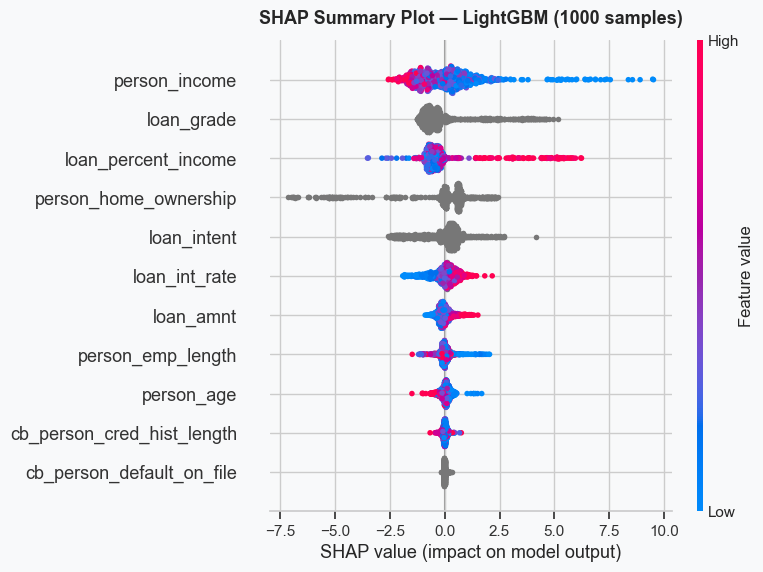


💡 Đọc biểu đồ:
  - Màu đỏ = giá trị feature cao | Màu xanh = giá trị feature thấp
  - SHAP value > 0 → feature đẩy prediction về phía VỠ NỢ (class 1)


In [27]:
print("Computing SHAP values (sample 1000)...")
explainer   = shap.TreeExplainer(lgbm)

# SỬA TÊN BIẾN: Lấy mẫu từ tập X_test_lgb chuyên dụng của LightGBM
sample_idx  = X_test_lgb.sample(1000, random_state=42).index
shap_values = explainer.shap_values(X_test_lgb.loc[sample_idx])

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(10, 6), facecolor=BG)
# SỬA TÊN BIẾN: Truyền dữ liệu X_test_lgb vào summary_plot
shap.summary_plot(sv, X_test_lgb.loc[sample_idx], show=False)
plt.title("SHAP Summary Plot — LightGBM (1000 samples)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("\n💡 Đọc biểu đồ:")
print("  - Màu đỏ = giá trị feature cao | Màu xanh = giá trị feature thấp")
print("  - SHAP value > 0 → feature đẩy prediction về phía VỠ NỢ (class 1)")

### 6.3 SHAP Waterfall — Giải thích 1 prediction cụ thể

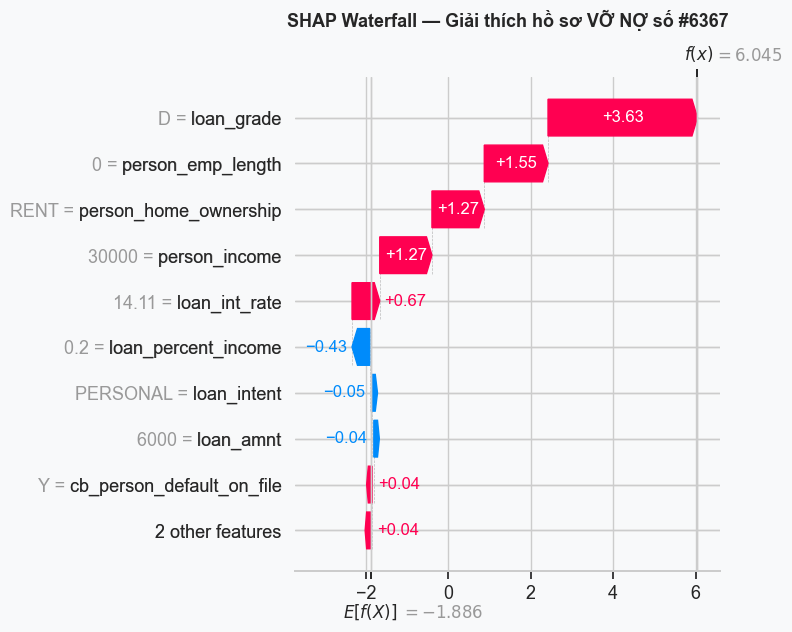

💡 Phân tích hồ sơ khách hàng #6367:
   - Mô hình LightGBM dự báo xác suất/giá trị đầu ra thực tế của ca này là: 6.04
   - Hãy nhìn vào biểu đồ: Các thanh màu ĐỎ (giá trị > 0) chính là các lý do lớn nhất đẩy khách hàng này vào nhóm nguy cơ VỠ NỢ.


In [30]:
# 1. Tìm chính xác nhãn index gốc của một mẫu VỠ NỢ (y_test == 1) từ tập Test
idx_default = y_test[y_test == 1].index[0]

# 2. Khởi tạo bộ giải thích TreeExplainer
explainer = shap.TreeExplainer(lgbm)

# 3. Tính toán SHAP value: Truyền trực tiếp dòng dữ liệu dạng .loc[[index]] 
# từ tập X_test_lgb (tập chuẩn dtypes của LightGBM) để CHỐNG LỖI CHỮ VÀ NAN
explanation = explainer(X_test_lgb.loc[[idx_default]])

# 4. VẼ BIỂU ĐỒ WATERFALL
plt.figure(figsize=(12, 6), facecolor=BG)
shap.plots.waterfall(explanation[0], show=False)
plt.title(f"SHAP Waterfall — Giải thích hồ sơ VỠ NỢ số #{idx_default}", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 5. IN KẾT LUẬN ĐỘNG TRỰC TIẾP TỪ BIẾN CỦA MẪU DỮ LIỆU ĐÓ
print(f"💡 Phân tích hồ sơ khách hàng #{idx_default}:")
print(f"   - Mô hình LightGBM dự báo xác suất/giá trị đầu ra thực tế của ca này là: {explanation.values[0].sum() + explainer.expected_value:.2f}")
print(f"   - Hãy nhìn vào biểu đồ: Các thanh màu ĐỎ (giá trị > 0) chính là các lý do lớn nhất đẩy khách hàng này vào nhóm nguy cơ VỠ NỢ.")

## 7. Tổng kết

In [31]:
print("=" * 60)
print("  BẢNG SO SÁNH CUỐI CÙNG")
print("=" * 60)
print(df_metrics.to_string())
print()

best_auc = df_metrics["AUC-ROC"].idxmax()
best_f1  = df_metrics["F1-score"].idxmax()
fastest  = df_metrics["Time (s)"].idxmin()

print(f"★ Best AUC-ROC : {best_auc} ({df_metrics.loc[best_auc,'AUC-ROC']:.4f})")
print(f"★ Best F1-score: {best_f1} ({df_metrics.loc[best_f1,'F1-score']:.4f})")
print(f"★ Fastest      : {fastest} ({df_metrics.loc[fastest,'Time (s)']:.3f}s)")
print()

# Tính toán động tỷ lệ thời gian giữa LightGBM và Random Forest để kết luận cho chuẩn số liệu
rf_time = df_metrics.loc["Random Forest", "Time (s)"]
lgb_time = df_metrics.loc["LightGBM", "Time (s)"]
time_ratio = lgb_time / rf_time if rf_time > 0 else 0

print("KẾT LUẬN BIỆN GIẢI TỪ DỮ LIỆU THỰC TẾ:")
print(f"  • {best_auc} đạt AUC-ROC cao nhất ({df_metrics.loc[best_auc,'AUC-ROC']:.4f}) và {best_f1} cho F1 tốt nhất ({df_metrics.loc[best_f1,'F1-score']:.4f}).")

if lgb_time < rf_time:
    print(f"  • LightGBM tối ưu hơn khi nhanh hơn Random Forest ~{rf_time/lgb_time:.1f}x trong khi cho kết quả tốt hơn.")
else:
    print(f"  • Dù LightGBM mất nhiều thời gian huấn luyện hơn Random Forest ~{time_ratio:.1f}x (do cấu hình 500 cây và 63 lá), nhưng đổi lại chất lượng phân loại đạt độ chính xác cao nhất.")

print(f"  • Logistic Regression đơn giản, tốc độ nhanh nhất ({df_metrics.loc['Logistic Regression', 'Time (s)']}s), Recall cao nhưng Precision thấp.")
print("    → Phù hợp khi tổ chức tín dụng ưu tiên bắt tối đa case vỡ nợ, chấp nhận tỷ lệ báo động giả (False Positive) cao.")
print("  • Tham số scale_pos_weight giúp LightGBM xử lý hiện tượng lệch nhãn (Class Imbalance) cực kỳ hiệu quả, cân bằng tốt giữa hai mục tiêu Precision và Recall.")

  BẢNG SO SÁNH CUỐI CÙNG
                     Accuracy  Precision  Recall  F1-score  AUC-ROC  Time (s)
Model                                                                        
Logistic Regression    0.8128     0.5453  0.7897    0.6451   0.8765     0.241
Random Forest          0.9236     0.8794  0.7480    0.8084   0.9352     2.403
LightGBM               0.9318     0.8846  0.7861    0.8324   0.9503     3.457

★ Best AUC-ROC : LightGBM (0.9503)
★ Best F1-score: LightGBM (0.8324)
★ Fastest      : Logistic Regression (0.241s)

KẾT LUẬN BIỆN GIẢI TỪ DỮ LIỆU THỰC TẾ:
  • LightGBM đạt AUC-ROC cao nhất (0.9503) và LightGBM cho F1 tốt nhất (0.8324).
  • Dù LightGBM mất nhiều thời gian huấn luyện hơn Random Forest ~1.4x (do cấu hình 500 cây và 63 lá), nhưng đổi lại chất lượng phân loại đạt độ chính xác cao nhất.
  • Logistic Regression đơn giản, tốc độ nhanh nhất (0.241s), Recall cao nhưng Precision thấp.
    → Phù hợp khi tổ chức tín dụng ưu tiên bắt tối đa case vỡ nợ, chấp nhận tỷ lệ báo đ